# Point to Point Link
---


In [1]:
# %load_ext autoreload
# %autoreload 2
# %matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import xarray as xr
from hics import HCS
from hics.plotting import view_surface_profile, viewcs, plotnlcd
from scipy.spatial.transform import Rotation

from xant import ureg
from xant.antenna import common
from xant.propagation import rflink

# pv.set_jupyter_backend("trame")

In [2]:
llatx = (39.998918, -105.28254, 21)
hcstx = HCS.from_crs((llatx[0] * ureg.degree, llatx[1] * ureg.degree, llatx[2] * ureg.m), hagl=True)

llarx = (39.993457, -105.264, 60)
hcsrx = HCS.from_crs((llarx[0] * ureg.degree, llarx[1] * ureg.degree, llarx[2] * ureg.m), hagl=True)


2026-04-17 14:28:09.366 | INFO     | hics.geo.downloader:build_index:231 - Starting index build/update for C:\Users\robsc\AppData\Local\hics\terrain...
2026-04-17 14:28:09.407 | INFO     | hics.geo.downloader:build_index:312 - Index build/update complete.
2026-04-17 14:28:09.409 | INFO     | hics.geo.downloader:get_geospatial_data:570 - Searching bounding box -105.28264,39.998818,-105.28244,39.99901800000001
2026-04-17 14:28:09.414 | INFO     | hics.geo.downloader:query:353 - R-tree query found 31 tiles intersecting the AOI.
2026-04-17 14:28:09.415 | INFO     | hics.geo.downloader:get_geospatial_data:573 - Found 3dep-seamless files {'n41w106-1': {'source': '3dep-seamless', 'tile_name': 'n41w106-1', 'date': 20150717, 'path': 'C:\\Users\\robsc\\AppData\\Local\\hics\\terrain\\USGS30-n41w106-1-30m-20150717.tif', 'bbox': [-106.00166666666748, 39.99833333285117, -104.99833333285117, 41.00166666666747], 'gsd': 30}, 'n40w106-1': {'source': '3dep-seamless', 'tile_name': 'n40w106-1', 'date': 201

In [3]:
mounttx = HCS(
    (0, 0, 0) * ureg.m,
    rotation=Rotation.from_euler("ZXZ", [0, 91, 111], degrees=True),
    reference=hcstx,
)

mountrx = HCS(
    (0, 0, 0) * ureg.m,
    rotation=Rotation.from_euler("ZXZ", [0, 89, 291], degrees=True),
    reference=hcsrx,
)

In [4]:
pltter = viewcs(mounttx, hcstx, vector_length=200)
pltter = viewcs(mountrx, hcstx, ax=pltter, vector_length=200)
pltter.show()

Widget(value='<iframe src="http://localhost:64313/index.html?ui=P_0x16fddfeb770_0&reconnect=auto" class="pyvis…

2026-04-17 14:28:18.653 | INFO     | hics.geo.downloader:build_index:231 - Starting index build/update for C:\Users\robsc\AppData\Local\hics\terrain...
2026-04-17 14:28:18.659 | INFO     | hics.geo.downloader:build_index:312 - Index build/update complete.
2026-04-17 14:28:18.660 | INFO     | hics.geo.downloader:get_geospatial_data:570 - Searching bounding box -105.28264,39.998818000000234,-105.28244,39.99901800000024
2026-04-17 14:28:18.664 | INFO     | hics.geo.downloader:query:353 - R-tree query found 31 tiles intersecting the AOI.
2026-04-17 14:28:18.665 | INFO     | hics.geo.downloader:get_geospatial_data:573 - Found 3dep-seamless files {'n41w106-1': {'source': '3dep-seamless', 'tile_name': 'n41w106-1', 'date': 20150717, 'path': 'C:\\Users\\robsc\\AppData\\Local\\hics\\terrain\\USGS30-n41w106-1-30m-20150717.tif', 'bbox': [-106.00166666666748, 39.99833333285117, -104.99833333285117, 41.00166666666747], 'gsd': 30}, 'n40w106-1': {'source': '3dep-seamless', 'tile_name': 'n40w106-1', 'd

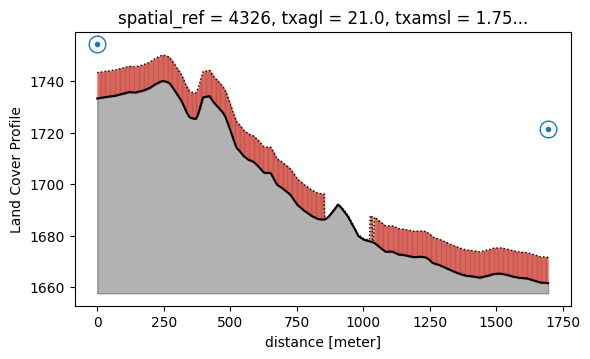

In [5]:
res = view_surface_profile(mounttx, mountrx, aspect=0.1)

2026-04-17 14:28:26.600 | INFO     | hics.geo.downloader:build_index:231 - Starting index build/update for C:\Users\robsc\AppData\Local\hics\terrain...
2026-04-17 14:28:26.608 | INFO     | hics.geo.downloader:build_index:312 - Index build/update complete.
2026-04-17 14:28:26.611 | INFO     | hics.geo.downloader:get_geospatial_data:570 - Searching bounding box -105.331491,39.925472,-105.102838,40.10296
2026-04-17 14:28:26.616 | INFO     | hics.geo.downloader:query:353 - R-tree query found 41 tiles intersecting the AOI.
2026-04-17 14:28:26.617 | INFO     | hics.geo.downloader:get_geospatial_data:573 - Found 3dep-seamless files {'n41w106-1': {'source': '3dep-seamless', 'tile_name': 'n41w106-1', 'date': 20150717, 'path': 'C:\\Users\\robsc\\AppData\\Local\\hics\\terrain\\USGS30-n41w106-1-30m-20150717.tif', 'bbox': [-106.00166666666748, 39.99833333285117, -104.99833333285117, 41.00166666666747], 'gsd': 30}, 'n40w106-1': {'source': '3dep-seamless', 'tile_name': 'n40w106-1', 'date': 20180328, 

<Axes: title={'center': 'spatial_ref = 4326'}, xlabel='lon', ylabel='lat'>

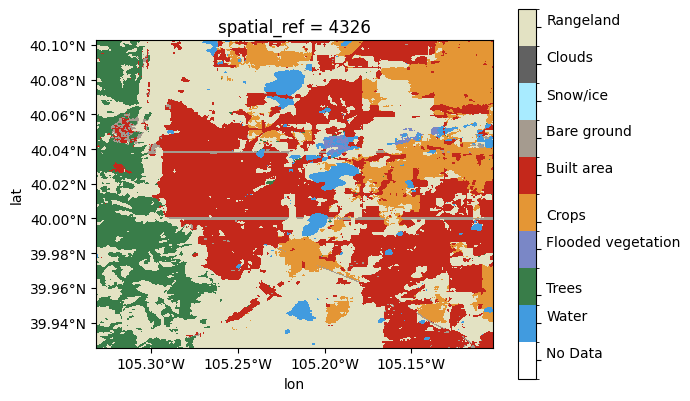

In [6]:
plotnlcd([(39.925472, -105.331491), (40.102960, -105.102838)])


2026-04-17 14:28:33.073 | INFO     | hics.geo.downloader:build_index:231 - Starting index build/update for C:\Users\robsc\AppData\Local\hics\terrain...
2026-04-17 14:28:33.080 | INFO     | hics.geo.downloader:build_index:312 - Index build/update complete.
2026-04-17 14:28:33.082 | INFO     | hics.geo.downloader:get_geospatial_data:570 - Searching bounding box -105.28254,39.993457,-105.264,39.998918
2026-04-17 14:28:33.086 | INFO     | hics.geo.downloader:query:353 - R-tree query found 31 tiles intersecting the AOI.
2026-04-17 14:28:33.087 | INFO     | hics.geo.downloader:get_geospatial_data:573 - Found 3dep-seamless files {'n41w106-1': {'source': '3dep-seamless', 'tile_name': 'n41w106-1', 'date': 20150717, 'path': 'C:\\Users\\robsc\\AppData\\Local\\hics\\terrain\\USGS30-n41w106-1-30m-20150717.tif', 'bbox': [-106.00166666666748, 39.99833333285117, -104.99833333285117, 41.00166666666747], 'gsd': 30}, 'n40w106-1': {'source': '3dep-seamless', 'tile_name': 'n40w106-1', 'date': 20180328, 'pa

<Axes: title={'center': 'spatial_ref = 4326'}, xlabel='lon', ylabel='lat'>

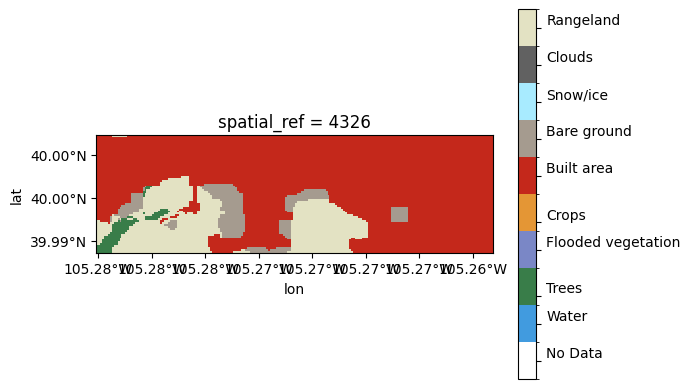

In [7]:
plotnlcd([llatx[:2], llarx[:2]])

In [8]:
# Frequency and wavelength
f0 = 5.2 * ureg.GHz
lam0 = (ureg.speed_of_light / f0).to("cm")
f0 = [5.2] * ureg.GHz

# Create antenna objects to emulate the Ubiquiti airFiber 5XHD
eta = 0.8
ant0 = common.CircularAperture(lam0 * 6, f0, mounttx) * np.sqrt(eta)
ant1 = common.CircularAperture(lam0 * 6, f0, mountrx) * np.sqrt(eta)

In [9]:
tx_power = 29 * ureg.dBm
rx_power, prop_loss, incident_pol, txcs, rxcs = rflink.calculate_spatial_link(
    ant0,
    tx_power,
    ant1,
    propagation="itm_rflink",
)
rx_power

2026-04-17 14:28:35.869 | DEBUG    | xant.propagation.propagators:itm_rflink:157 - ITM PROP


<xarray.DataArray ()> Size: 8B
<Quantity(-21.25240255770172, 'decibelmilliwatt')>
Coordinates: (12/31)
    frequency      float64 8B 5.2e+09
    lat            float64 8B <Quantity(39.993457000000454, 'degree')>
    lon            float64 8B <Quantity(-105.264, 'degree')>
    h              float64 8B <Quantity(1721.6064835079014, 'meter')>
    time           float64 8B 0.5
    location       float64 8B 0.5
    ...             ...
    rxagl          float64 8B 60.0
    rxamsl         float64 8B 1.722e+03
    distance       float64 8B <Quantity(1695.4290944920092, 'meter')>
    tx_power       int64 8B <Quantity(29, 'decibelmilliwatt')>
    tx_gain        float64 8B <Quantity(1135.158240902125, 'dimensionless')>
    rx_gain        float64 8B <Quantity(1135.5994917608543, 'dimensionless')>
Attributes:
    coordinate_frame:  phitheta
    long_name:         Power
    units:             dBm
    description:       Received Power

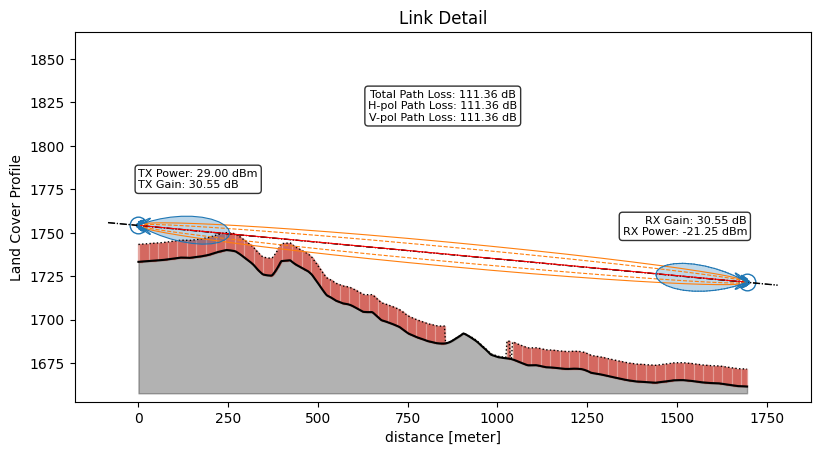

In [10]:
ax = rflink.view_link_horizon(
    ant0,
    ant1,
    rx_power,
    incident_pol,
    prop_loss,
    aspect=0.2,
)